Import libraries and the data set

In [3]:
import pandas as pd
import numpy as np
from numpy import *
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, classification_report
from itertools import product
import matplotlib.pyplot as plt
import seaborn as sns
import sys

df = pd.read_csv("data/forestfires.csv")
y_label = 'area_bin'
df

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.00
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.00
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.00
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.00
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.00


Some feature engineering, which include:
1. label encoding month and day column
2. take the log of area column
3. cutting the area target into 6 bins

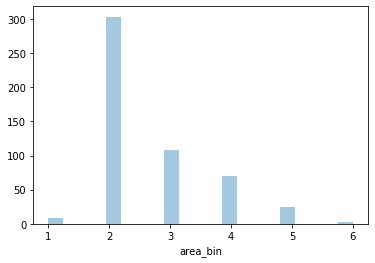

In [189]:
df_pre = df.copy()
df_pre['month'] = df_pre['month'].astype('category').cat.codes
df_pre['day'] = df_pre['day'].astype('category').cat.codes
df_pre['area'] = ma.log(df_pre['area'].values).filled(0)
area_labels = [1, 2, 3, 4, 5, 6]
df_pre['area_bin'] = pd.cut(df_pre['area'], include_lowest=True, bins=6, labels=area_labels)
df_pre.drop(columns=['area'], inplace=True)
sns.distplot(df_pre['area_bin'], kde=False)

Oversample the dataset using SMOTE

In [7]:
from imblearn.over_sampling import SMOTE, ADASYN
from tensorflow.python.keras import backend as k
df_x = df_pre.drop(columns=[y_label])
df_y = df_pre[y_label]
oversample = ADASYN(sampling_strategy='all', n_neighbors=2)
df_x_smote, df_y_smote = oversample.fit_resample(df_x, df_y)
df_y_smote

0       2
1       2
2       2
3       2
4       2
       ..
1805    6
1806    6
1807    6
1808    6
1809    6
Name: area_bin, Length: 1810, dtype: category
Categories (6, int64): [1 < 2 < 3 < 4 < 5 < 6]

70-30 split the dataset for training and testing 

In [8]:
x_train, x_test, y_train, y_test = train_test_split(df_x, df_y, test_size=0.3, random_state=1)
x_train_smote, x_test_smote, y_train_smote, y_test_smote = train_test_split(df_x_smote, df_y_smote, test_size=0.3, random_state=1)
y_test.value_counts()

2    95
3    31
4    19
5     7
1     3
6     1
Name: area_bin, dtype: int64

Self-implement two functions to calculate sensitivity and specificity.

In [9]:
def get_sensitivity(cm, label):
    labels = [1,2,3,4,5,6]
    #cm = confusion_matrix(y_test, y_pred, labels=labels)
    #print("{}/{}".format(cm[label - 1, label - 1], sum(cm[label - 1])))
    return cm[label - 1, label - 1] / sum(cm[label - 1])

def get_specificity(cm, label):
    indexes = [0,1,2,3,4,5]
    #cm = confusion_matrix(y_test, y_pred, labels=[1,2,3,4,5,6])
    tn = sum(np.diag(cm)) - cm[label - 1, label - 1]
    fp = sum([cm[i][label - 1] for i in indexes]) - cm[label - 1, label - 1]
    #print("tn:{}, fp:{}".format(tn, fp))
    return tn / (tn + fp)

def display_sens_spec(y_pred, y_test):
    labels = [1,2,3,4,5,6]
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    result = pd.DataFrame(columns=['label', 'sensitivity', 'specificity'])
    for idx, label in enumerate(labels):
        result.loc[idx] = [label, get_sensitivity(cm, label), get_specificity(cm, label)]
    result.set_index('label', inplace=True)
    return result    

Try decision tree classifier on the original dataset(without oversampling), with gini criterion and max_depth to be 3. It reached an accuracy of .61

In [172]:
dt_clf = DecisionTreeClassifier(criterion='gini', max_depth=3)
dt_clf.fit(x_train, y_train)
y_pred = dt_clf.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred, labels=[1,2,3,4,5,6]))
print(display_sens_spec(y_pred, y_test))

Accuracy: 0.6089743589743589
[[ 0  3  0  0  0  0]
 [ 0 95  0  0  0  0]
 [ 0 28  0  3  0  0]
 [ 0 19  0  0  0  0]
 [ 0  7  0  0  0  0]
 [ 0  1  0  0  0  0]]
       sensitivity  specificity
label                          
1.0            0.0     1.000000
2.0            1.0     0.000000
3.0            0.0     1.000000
4.0            0.0     0.969388
5.0            0.0     1.000000
6.0            0.0     1.000000


Try decision tree classifier on the oversampled dataset, with gini criterion and max_depth to be 3. It reached an accuracy of .173

In [190]:
dt_clf = DecisionTreeClassifier(criterion='gini', max_depth=3)
dt_clf.fit(x_train_smote, y_train_smote)
y_pred = dt_clf.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred, labels=[1,2,3,4,5,6]))
print(display_sens_spec(y_pred, y_test))

Accuracy: 0.17307692307692307
[[ 3  0  0  0  0  0]
 [47 16  0 19 10  3]
 [13  5  0 11  1  1]
 [10  2  0  6  0  1]
 [ 4  0  0  1  1  1]
 [ 0  0  0  0  0  1]]
       sensitivity  specificity
label                          
1.0       1.000000     0.244898
2.0       0.168421     0.611111
3.0       0.000000     1.000000
4.0       0.315789     0.403846
5.0       0.142857     0.702703
6.0       1.000000     0.812500


Accuracy: 0.11538461538461539
Accuracy: 0.07692307692307693
Accuracy: 0.17307692307692307
Accuracy: 0.34615384615384615
Accuracy: 0.3269230769230769
Accuracy: 0.46153846153846156
Accuracy: 0.5512820512820513
Accuracy: 0.6730769230769231
Accuracy: 0.717948717948718
Accuracy: 0.7692307692307693
Accuracy: 0.7884615384615384
Accuracy: 0.8076923076923077
Accuracy: 0.8205128205128205
Accuracy: 0.8205128205128205
Accuracy: 0.8461538461538461
Accuracy: 0.8397435897435898
Accuracy: 0.8461538461538461
Accuracy: 0.8333333333333334
Accuracy: 0.8205128205128205
Accuracy: 0.8269230769230769
Accuracy: 0.8076923076923077
Accuracy: 0.8333333333333334
Accuracy: 0.8269230769230769
Accuracy: 0.8205128205128205


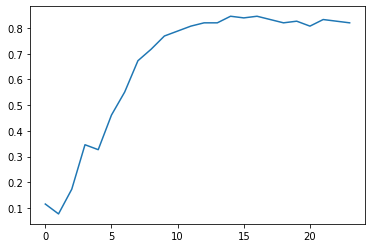

In [192]:
accuracies = []
for i in range(1, 25):
    dt_clf = DecisionTreeClassifier(criterion='gini', max_depth=i)
    dt_clf.fit(x_train_smote, y_train_smote)
    y_pred = dt_clf.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print("Accuracy:", acc)
plt.plot(accuracies)

Try grid search for parameter tuning. Self-implemented a grid search function.

In [10]:
def dict_product(d):
    keys = d.keys()
    for element in product(*d.values()):
        yield dict(zip(keys, element))
        
def GridSearchWithVal(model_class, param_grid, metrics='accuracy', cv=5, smote=False):
    combinations = list(dict_product(param_grid))
    max_metrics = 0
    best_comb = None
    X = x_train_smote if smote is True else x_train
    Y = y_train_smote if smote is True else y_train
    _x_test = x_test_smote if smote is True else x_test
    _y_test = y_test_smote if smote is True else y_test
    print("{} combinations in total. Metric: {}".format(len(combinations), metrics))
    for idx, comb in enumerate(combinations):
        model = model_class(**comb)
        model.fit(X, Y)
        y_preds = model.predict(_x_test)
        # print("y_preds:{}".format(y_preds))
        # print("y_test:{}".format(y_test.values))
        error = 0;

        #scores = cross_val_score(model, X, Y, cv=cv, scoring=metrics)
        n_correct = sum(y_preds == _y_test)
        acc = float(n_correct) / len(y_preds)
        metrics_num = acc

        if metrics_num > max_metrics:
            max_metrics = metrics_num
            best_comb = comb
        progress_str = "{} / {}, best comb: {}, best score: {}".format(idx + 1, len(combinations), best_comb, max_metrics)
        sys.stdout.write('\r' + progress_str)

    print("best params:{}".format(best_comb))
    print("max {}: {}".format(metrics, max_metrics))
    return best_comb

Grid search several important parameters using the oversampled dataset.

In [182]:
dt_param_grid = { "criterion" : ['gini', 'entropy'],
                  "splitter" : ["best", "random"],
                  "max_depth": [5, 7, None],
                  "max_features": [None, 4, 5, 6, 7, 10, 11],
                  "min_samples_split": [2, 3, 4, 5, 6],
                  "min_samples_leaf": [1, 2, 3, 5],
                  #"bootstrap": [True, False]
                 }
dt_best_comb = GridSearchWithVal(DecisionTreeClassifier, dt_param_grid, smote=True)

1680 combinations in total. Metric: accuracy
1680 / 1680, best comb: {'criterion': 'gini', 'splitter': 'best', 'max_depth': None, 'max_features': 5, 'min_samples_split': 2, 'min_samples_leaf': 1}, best score: 0.7974217311233885best params:{'criterion': 'gini', 'splitter': 'best', 'max_depth': None, 'max_features': 5, 'min_samples_split': 2, 'min_samples_leaf': 1}
max accuracy: 0.7974217311233885


The grid search reached the max accuracy of .797 on test set with gini criterion, "best" splitter, no limit on max_depth, 5 max features, 2 min samples splits and 1 min sample leaf.

Try boosting algorithm. Take Gradient Boosting here to see if we could get higher accuracy.

In [14]:
gb_param_grid = {"n_estimators" : [500, 800, 1000, 1200],
                  "loss" : ["deviance"],
                  "learning_rate": [0.04, 0.05, 0.06],
                  "max_depth": [5, 6, 7, None],
                  "min_samples_leaf": [1, 5, 10],
                  "max_features": [4, 5, 6, 7, None] 
                }
gbc_best_param = GridSearchWithVal(GradientBoostingClassifier, gb_param_grid, smote=True)

720 combinations in total. Metric: accuracy
720 / 720, best comb: {'n_estimators': 800, 'loss': 'deviance', 'learning_rate': 0.05, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 7}, best score: 0.9060773480662984best params:{'n_estimators': 800, 'loss': 'deviance', 'learning_rate': 0.05, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 7}
max accuracy: 0.9060773480662984


Grid search showed that GradientBoosting trees could reach an accuracy of .906 on testing set, with 800 trees, deviance loss, 0.05 learning rate, no limit on max depth, 1 min samples leaf and 7 max features.

In [196]:
gb_best = GradientBoostingClassifier(**gbc_best_param)
gb_best.fit(x_train_smote, y_train_smote)
y_pred = gb_best.predict(x_test_smote)
acc = accuracy_score(y_test_smote, y_pred)
print("Accuracy:", acc)
print(confusion_matrix(y_test_smote, y_pred, labels=[1,2,3,4,5,6]))
print(display_sens_spec(y_pred, y_test_smote))

Accuracy: 0.8747697974217311
[[ 96   1   0   0   0   0]
 [  2  57  24  11   3   0]
 [  1  10  61   5   1   0]
 [  0   3   5  76   2   0]
 [  0   0   0   0 106   0]
 [  0   0   0   0   0  79]]
       sensitivity  specificity
label                          
1.0       0.989691     0.992147
2.0       0.587629     0.967593
3.0       0.782051     0.934537
4.0       0.883721     0.961446
5.0       1.000000     0.984000
6.0       1.000000     1.000000
